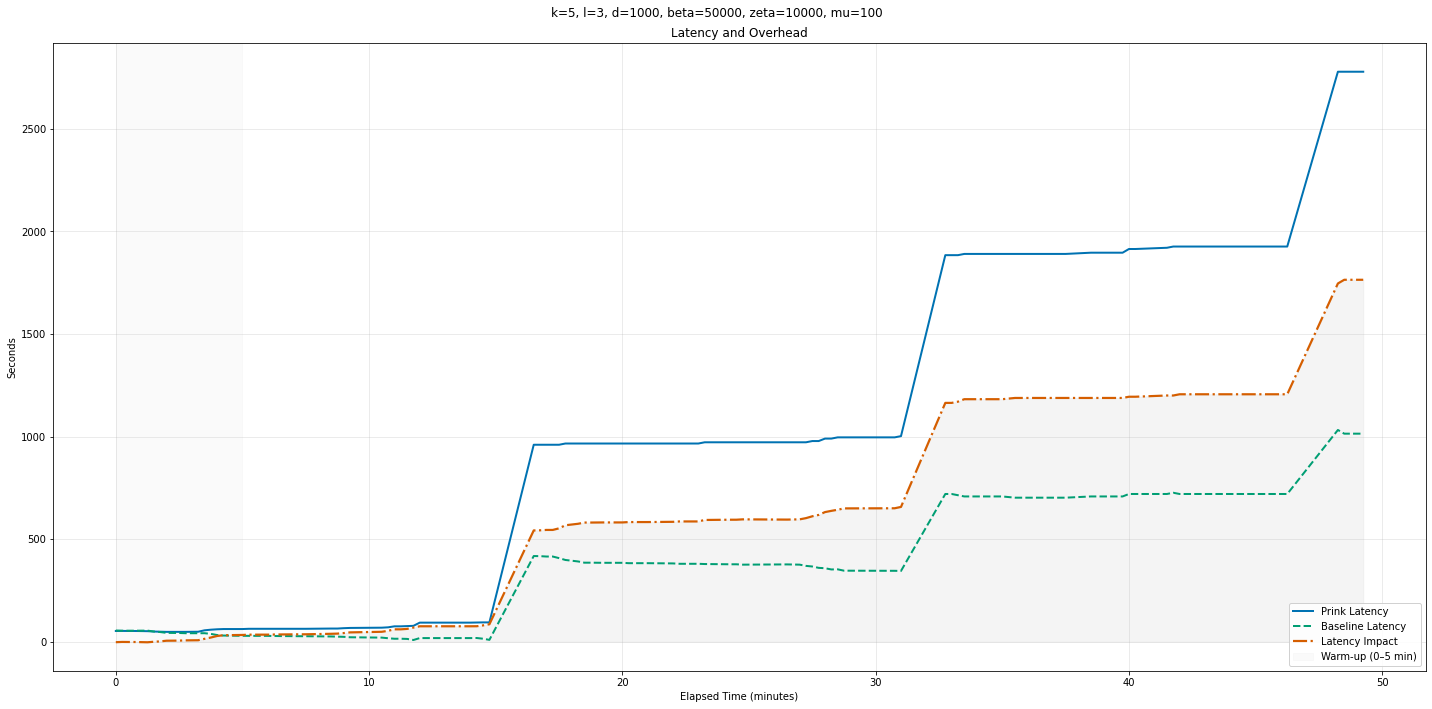

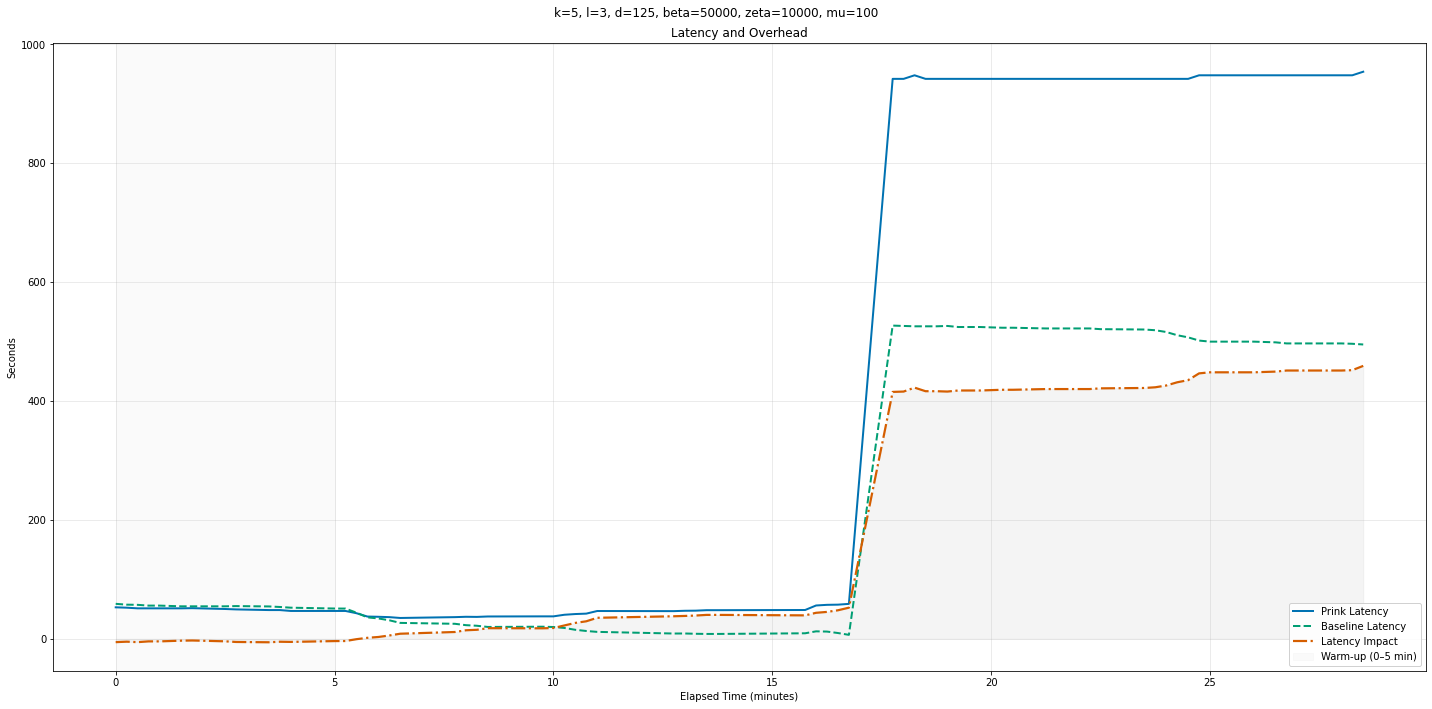

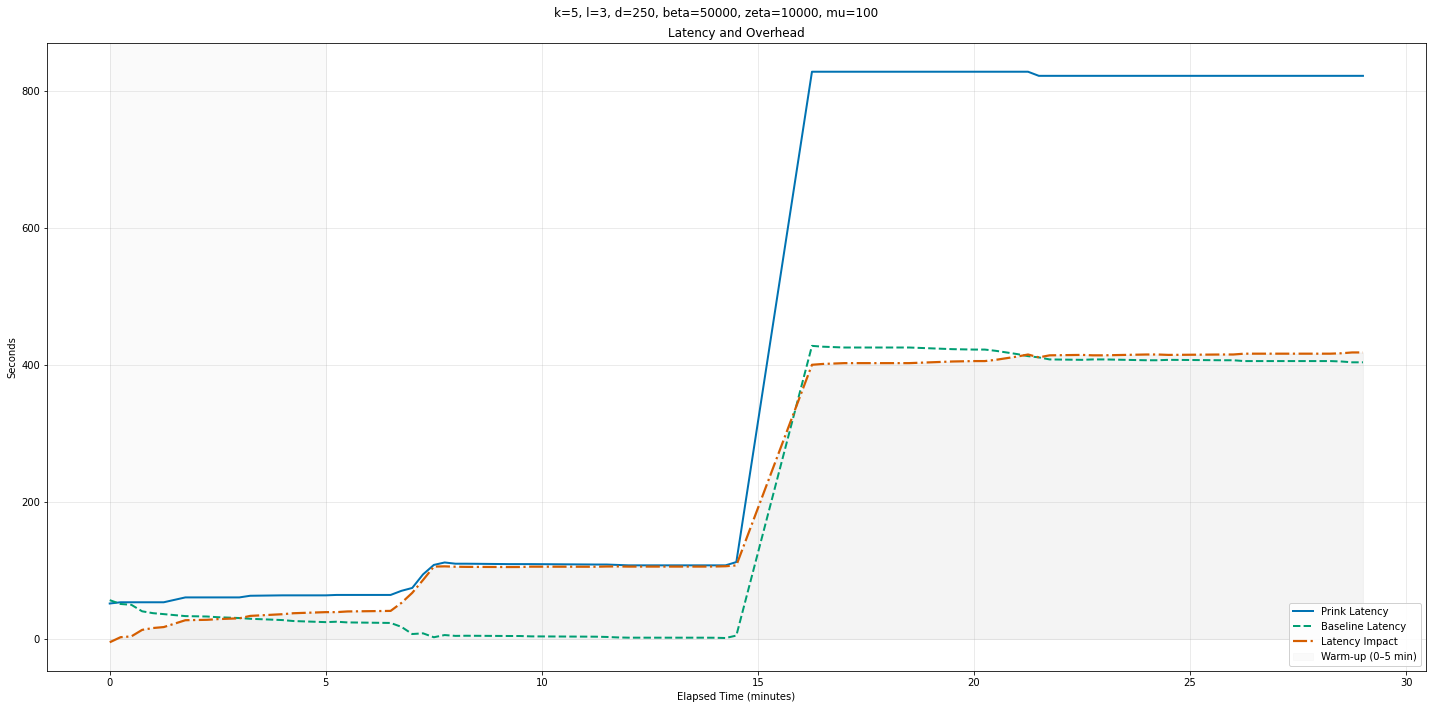

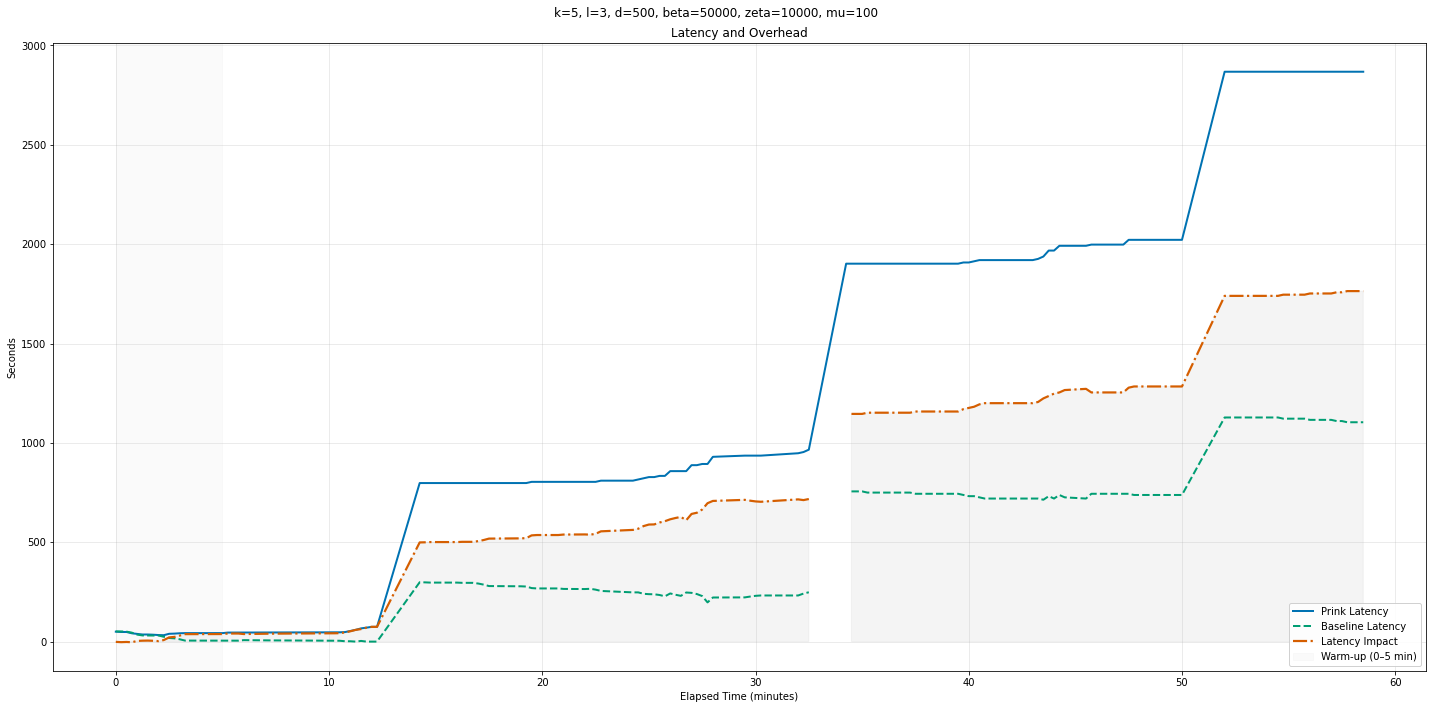

Saved combined plot to: ./data/combined_latency_impact_20250812_140512.png


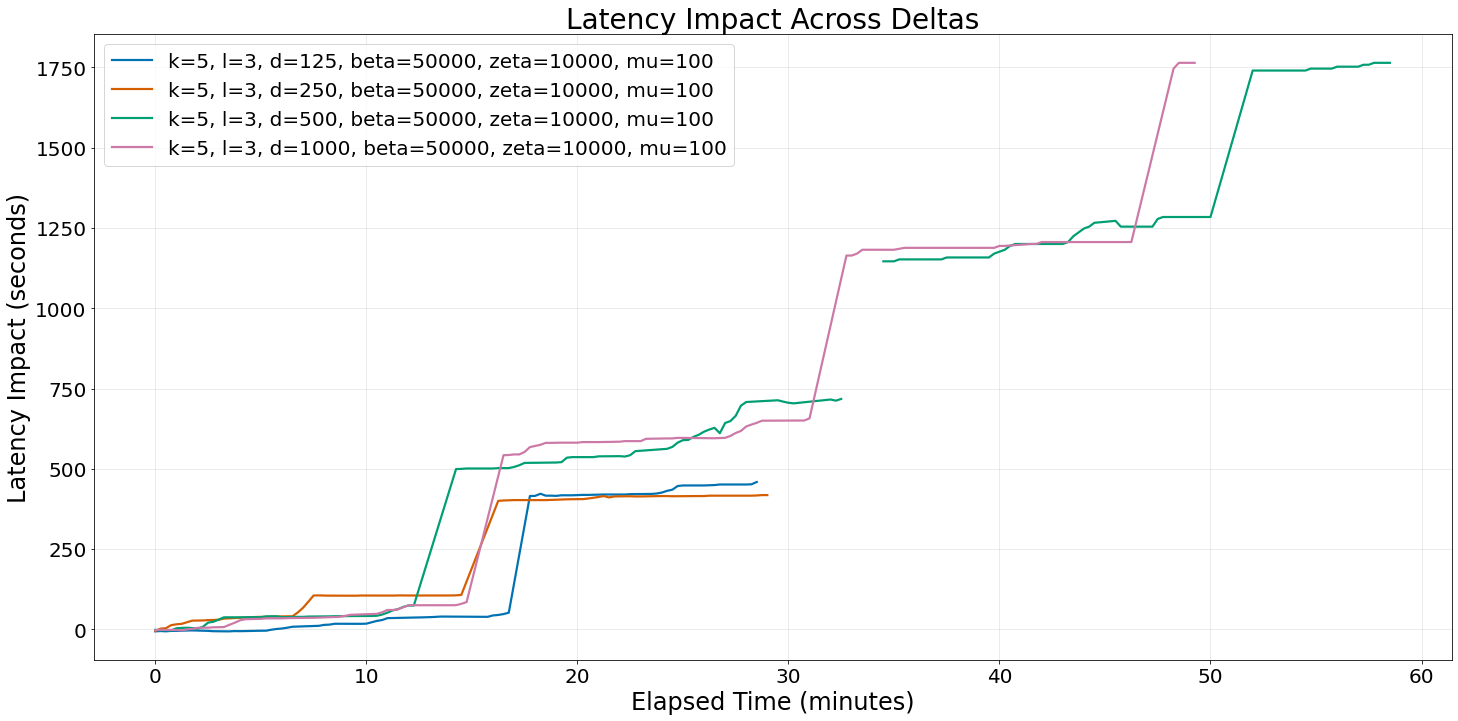

Apples-to-apples window: 5.00–28.50 min (auto 0.00–28.50)
Saved combined plot to: ./data/combined_latency_impact_20250812_140513.png


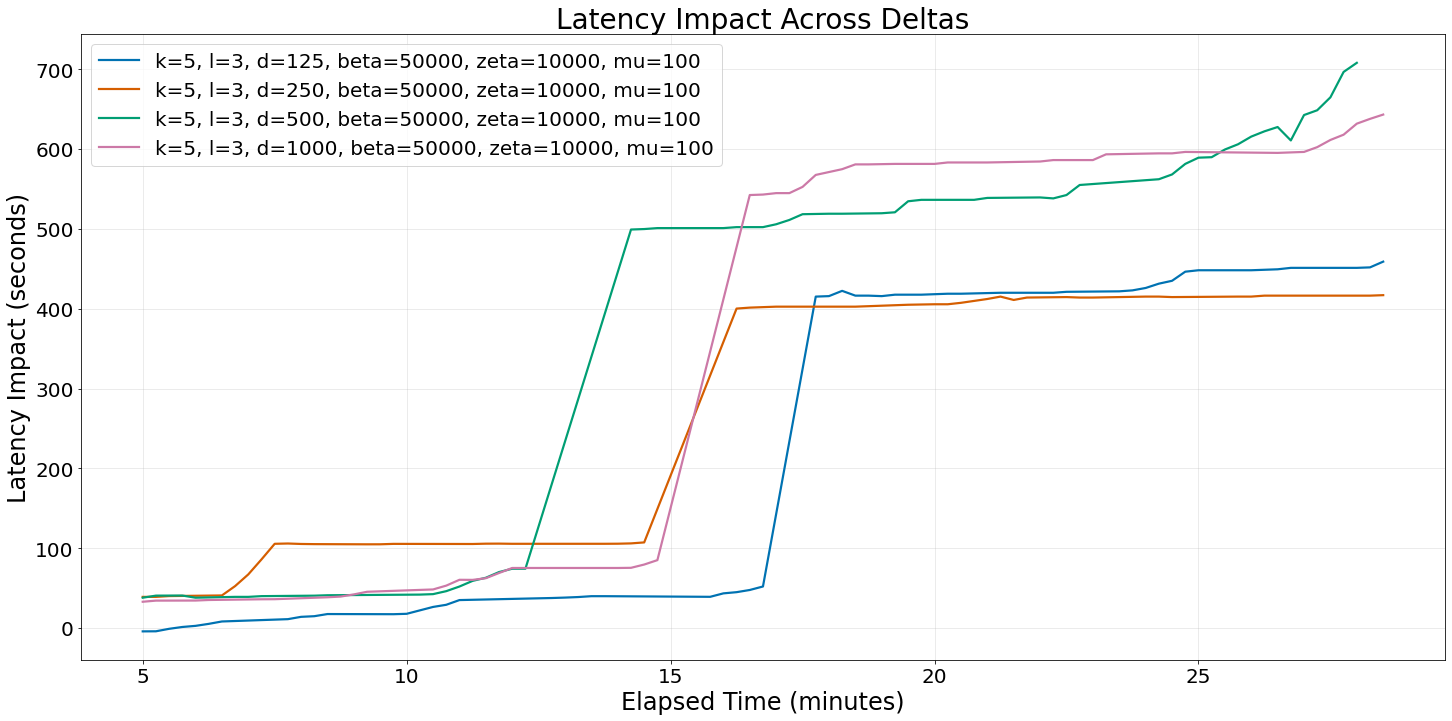

,file,k,l,d,beta,zeta,mu,rows,impact_median_s,impact_mean_s,impact_p90_s,impact_p95_s
1,Latency_k5_l3_d125_beta50000_zeta10000_mu100.csv,5,3,125,50000,10000,100,68,39.970,191.803824,448.2,450.57
2,Latency_k5_l3_d250_beta50000_zeta10000_mu100.csv,5,3,250,50000,10000,100,68,106.705,231.601029,415.2,416.40
3,Latency_k5_l3_d500_beta50000_zeta10000_mu100.csv,5,3,500,50000,10000,100,142,627.600,766.381557,1740.0,1746.00
0,Latency_k5_l3_d1000_beta50000_zeta10000_mu100_...,5,3,1000,50000,10000,100,102,583.800,610.619804,1200.0,1206.00


In [13]:
# === Robust multi-dataset latency analysis & comparison ===
import os, re, pandas as pd, numpy as np, matplotlib.pyplot as plt
from datetime import datetime

BASE_DIR = "./data/"  # <- notebook folder

# ---------- parsing helpers ----------
def parse_config(filename: str):
    base = os.path.basename(filename).replace(".csv", "")
    parts = re.split(r"[_\-\s]+", base)
    params = {}
    for part in parts:
        p = part.lower()
        if re.fullmatch(r"k\d+", p): params["k"] = int(p[1:])
        elif re.fullmatch(r"l\d+", p): params["l"] = int(p[1:])
        elif re.fullmatch(r"d\d+", p): params["d"] = int(p[1:])
        elif re.fullmatch(r"delta\d+", p): params["d"] = int(p[5:])
        elif re.fullmatch(r"d=\d+", p): params["d"] = int(p.split("=",1)[1])
        elif p.startswith("beta"): params["beta"] = int(re.sub(r"^beta","",p))
        elif p.startswith("zeta"): params["zeta"] = int(re.sub(r"^zeta","",p))
        elif p.startswith("mu"):   params["mu"]   = int(re.sub(r"^mu","",p))
    return params

def label_from_params(params: dict, extra_suffix: str = ""):
    bits = [f"{k}={params[k]}" for k in ["k","l","d","beta","zeta","mu"] if k in params]
    if extra_suffix: bits.append(extra_suffix)
    return ", ".join(bits) if bits else extra_suffix or "config"

def _to_seconds_series(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()

    # HH:MM:SS durations (if you ever have them in latency columns)
    has_colon = s.str.contains(":")
    out = pd.Series(index=s.index, dtype="float64")
    if has_colon.any():
        td = pd.to_timedelta(s[has_colon], errors="coerce")
        out.loc[has_colon] = td.dt.total_seconds()

    # numeric + optional unit
    rest = s[~has_colon]
    ex = rest.str.extract(r'^\s*([-+]?\d+(?:[.,]\d+)?)(?:\s*([A-Za-z]+))?\s*$')
    num = pd.to_numeric(ex[0].str.replace(",", ".", regex=False), errors="coerce")
    unit = ex[1].str.lower().fillna("")

    factor = pd.Series(1.0, index=rest.index)
    factor[unit.isin(["ms","msec","millisecond","milliseconds"])] = 1/1000.0
    factor[unit.isin(["s","sec","secs","second","seconds",""])] = 1.0
    factor[unit.isin(["m","min","mins","minute","minutes"])] = 60.0

    out.loc[rest.index] = num * factor

    # final fallback
    missing = out.isna()
    if missing.any():
        out.loc[missing] = pd.to_numeric(rest[missing].str.replace(",", ".", regex=False), errors="coerce")

    return out

def read_latency_df(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    col = {c.lower(): c for c in df.columns}
    def pick(*names):
        for n in names:
            if n.lower() in col: return col[n.lower()]
        return None

    # accept "Time" for x-axis
    x  = pick("Elapsed Minutes","Elapsed Time (minutes)","Minutes","Time (min)","Elapsed_Minutes","Time")
    pr = pick("Prink Latency","Prink_Latency","PrinkLatency")
    bl = pick("Baseline Latency","Baseline_Latency","BaselineLatency")
    imp= pick("Latency Impact","Latency_Impact","Overhead","Latency Overhead")

    x_raw = df[x].astype(str).str.strip()

    # timestamps -> elapsed minutes
    ts = pd.to_datetime(x_raw, errors="coerce")
    if ts.notna().mean() > 0.8:
        minutes = (ts - ts.iloc[0]).dt.total_seconds() / 60.0
    else:
        # durations like MM:SS / HH:MM:SS
        td = pd.to_timedelta(x_raw, errors="coerce")
        if td.notna().mean() > 0.8:
            minutes = td.dt.total_seconds() / 60.0
        else:
            # plain numbers; heuristic: very large => seconds
            minutes = pd.to_numeric(x_raw.str.replace(",", ".", regex=False), errors="coerce")
            if minutes.max(skipna=True) and float(minutes.max()) > 1000:
                minutes = minutes / 60.0

    pr_s = _to_seconds_series(df[pr])
    bl_s = _to_seconds_series(df[bl])
    imp_s = _to_seconds_series(df[imp]) if imp is not None else (pr_s - bl_s)

    # ensure numeric dtypes for plotting
    out = pd.DataFrame({
        "Elapsed Minutes": minutes.astype(float),
        "Prink Latency":   pr_s.astype(float),
        "Baseline Latency":bl_s.astype(float),
        "Latency Impact":  imp_s.astype(float),
    })
    return out

# ---------- discovery ----------
def discover_latency_files(base_dir: str):
    files = []
    for f in os.listdir(base_dir):
        name = f.lower()
        if name.endswith(".csv") and "latency" in name and "summary" not in name:
            files.append(os.path.join(base_dir, f))
    return sorted(files)

# ---------- plotting ----------
# --- Color-blind friendly styles (Okabe–Ito) ---
CB_COLORS      = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#56B4E9', '#E69F00', '#000000']
CB_LINESTYLES  = ['-','--','-.',':']

def _style_for(i: int):
    # cycle colors first, then linestyles; no markers
    return dict(
        color     = CB_COLORS[i % len(CB_COLORS)],
        linestyle = CB_LINESTYLES[(i // len(CB_COLORS)) % len(CB_LINESTYLES)],
    )

def plot_per_file(df: pd.DataFrame, params: dict, title_suffix: str = "", warmup_minutes: float = 5.0):
    x  = df["Elapsed Minutes"].astype(float).to_numpy()
    pr = df["Prink Latency"].astype(float).to_numpy()
    bl = df["Baseline Latency"].astype(float).to_numpy()
    imp= df["Latency Impact"].astype(float).to_numpy()

    st_pr  = dict(color='#0072B2', linestyle='-')
    st_bl  = dict(color='#009E73', linestyle='--')
    st_imp = dict(color='#D55E00', linestyle='-.')

    plt.figure(figsize=(20,10))
    plt.plot(x, pr,  label="Prink Latency",    linewidth=2,  **st_pr)
    plt.plot(x, bl,  label="Baseline Latency", linewidth=2,  **st_bl)
    plt.plot(x, imp, label="Latency Impact",   linewidth=2.2,**st_imp)

    plt.fill_between(x, imp, alpha=0.15, color='#BBBBBB')
    plt.axvspan(0, float(warmup_minutes), alpha=0.12, color='#DDDDDD', label=f"Warm-up (0–{warmup_minutes} min)")
    plt.title("Latency and Overhead")
    plt.suptitle(label_from_params(params, extra_suffix=title_suffix))
    plt.xlabel("Elapsed Time (minutes)")
    plt.ylabel("Seconds")
    plt.grid(True, alpha=0.3); plt.legend(framealpha=0.9); plt.tight_layout()
    plt.show()

def plot_overlay(
    datasets,
    clip_quantile=None,
    apples_to_apples=False,
    common_start=None,
    common_end=None
):
    if apples_to_apples:
        mins, maxs = [], []
        for _, df in datasets:
            x = df["Elapsed Minutes"].dropna().astype(float)
            if len(x):
                mins.append(float(x.min()))
                maxs.append(float(x.max()))
        if mins and maxs:
            auto_start = max(mins); auto_end = min(maxs)
            cs = auto_start if common_start is None else float(common_start)
            ce = auto_end   if common_end   is None else float(common_end)
            if ce <= cs:
                print(f"Computed common window invalid ({cs:.2f}–{ce:.2f}). Using raw overlay.")
                apples_to_apples = False
            else:
                common_start, common_end = cs, ce
                print(f"Apples-to-apples window: {common_start:.2f}–{common_end:.2f} min "
                      f"(auto {auto_start:.2f}–{auto_end:.2f})")
        else:
            apples_to_apples = False

    plt.figure(figsize=(20,10))
    for i, (label, df) in enumerate(datasets):
        style = _style_for(i)
        x = df["Elapsed Minutes"].astype(float)
        y = df["Latency Impact"].astype(float)
        if clip_quantile is not None:
            y = y.clip(upper=float(y.quantile(clip_quantile)))
        if apples_to_apples:
            m = (x >= common_start) & (x <= common_end)
            x, y = x[m], y[m]
        plt.plot(x.to_numpy(), y.to_numpy(), linewidth=2.2, label=label, **style)

    ttl = "Latency Impact Across Deltas"
    # if apples_to_apples:
    #     ttl += f" (common {common_start:.1f}–{common_end:.1f} min)"
    plt.title(ttl, fontsize=28)
    plt.xlabel("Elapsed Time (minutes)", fontsize=24); plt.ylabel("Latency Impact (seconds)", fontsize=24)
    plt.grid(True, alpha=0.3); plt.legend(framealpha=0.9); plt.tight_layout()

    # Styling
    plt.legend(fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)

    out = os.path.join(BASE_DIR, f"combined_latency_impact_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png")
    plt.savefig(out, dpi=180); print(f"Saved combined plot to: {out}")
    plt.show()

# ---------- run ----------
latency_paths = discover_latency_files(BASE_DIR)
datasets = []
summary_rows = []

for path in latency_paths:
    df = read_latency_df(path)
    params = parse_config(path) 

    title_suffix = os.path.basename(path).replace(".csv","")

    # per-file like your original
    plot_per_file(df, params, title_suffix="", warmup_minutes=5)

    # for overlay + summary
    label = label_from_params(params, extra_suffix="")
    datasets.append((label, df))
    impact = df["Latency Impact"].dropna().astype(float)
    summary_rows.append({
        "file": os.path.basename(path),
        **{k: params.get(k) for k in ["k","l","d","beta","zeta","mu"]},
        "rows": len(df),
        "impact_median_s": float(impact.median()) if not impact.empty else np.nan,
        "impact_mean_s": float(impact.mean()) if not impact.empty else np.nan,
        "impact_p90_s": float(impact.quantile(0.90)) if not impact.empty else np.nan,
        "impact_p95_s": float(impact.quantile(0.95)) if not impact.empty else np.nan,
    })

# move dataset[0] to last position in list
datasets.append(datasets.pop(0))
# raw overlay, color-blind friendly
plot_overlay(datasets)

# apples-to-apples (e.g., exclude warm-up by starting at 5 min)
plot_overlay(datasets, apples_to_apples=True, common_start=5)

# apples-to-apples + mild outlier clipping for readability
# plot_overlay(datasets, apples_to_apples=True, common_start=5, clip_quantile=0.99)

# summary table (optional; comment out if you don't need it)
summary = pd.DataFrame(summary_rows).sort_values(["k","l","d","beta","zeta","mu"], na_position="last")
summary

## Privacy Parameter Evaluation

In [14]:
# === Plots for privacy KPIs (k-anonymity + l-diversity) ===
# Assumes you already ran the KPI builder and have `per_file` and `by_config`.

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import matplotlib.colors as mcolors

SAVE_PNG = True
OUT_DIR = "."  # where to save figures
TS = datetime.now().strftime("%Y%m%d_%H%M%S")

# Okabe–Ito palette (color-blind friendly), no markers
CB_COLORS = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#56B4E9', '#E69F00', '#000000']
CB_LINESTYLES = ['-','--','-.',':']  # used only if we need multiple lines later

def _savefig(name):
    if SAVE_PNG:
        path = os.path.join(OUT_DIR, f"{name}_{TS}.png")
        plt.savefig(path, dpi=180, bbox_inches="tight")
        print(f"Saved: {path}")

def _metric_color(metric: str, i: int = 0):
    # k and l get distinct base colors; more series cycle through palette
    if metric == "k": return CB_COLORS[0]
    if metric == "l": return CB_COLORS[2]
    return CB_COLORS[i % len(CB_COLORS)]

def _autolabel_bars(ax, fmt="{:.1%}", padding=2, is_pct=True):
    for p in ax.patches:
        h = p.get_height()
        if np.isnan(h): continue
        txt = fmt.format(h if is_pct else h)
        ax.text(p.get_x() + p.get_width()/2, h + (0.01 if is_pct else max(0.01*h, 0.02)),
                txt, ha='center', va='bottom', fontsize=9, rotation=0)

def _ensure_sorted_numeric(df, col, ascending=False, top_n=None):
    d = df.copy()
    if col not in d.columns: return d.iloc[0:0]
    d = d.dropna(subset=[col])
    d = d.sort_values(col, ascending=ascending)
    if top_n is not None:
        d = d.head(top_n)
    return d

def plot_per_file_compliance(per_file, top_n=None):
    needed = {"file","metric","compliance_rate"}
    if per_file.empty or not needed.issubset(per_file.columns):
        print("Skipping per-file compliance plot (missing columns).")
        return
    d = _ensure_sorted_numeric(per_file, "compliance_rate", ascending=False, top_n=top_n)
    if d.empty:
        print("No data for per-file compliance plot.")
        return
    fig, ax = plt.subplots(figsize=(16, max(6, 0.35*len(d))))
    colors = [_metric_color(m) for m in d["metric"]]
    ax.barh(d["file"], d["compliance_rate"], color=colors)
    ax.invert_yaxis()
    ax.set_title("Compliance rate per file (Observed ≥ Defined)")
    ax.set_xlabel("Compliance rate")
    ax.set_xlim(0, 1)
    for i, (v, y) in enumerate(zip(d["compliance_rate"], ax.get_yticks())):
        ax.text(1.005, y, f"{d['metric'].iloc[i]}", va="center", fontsize=9)
    # annotate bars
    for i, (v, y) in enumerate(zip(d["compliance_rate"], range(len(d)))):
        ax.text(v + 0.01, y, f"{v:.1%}", va="center", fontsize=9)
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    _savefig("per_file_compliance")
    plt.show()

def plot_by_config_compliance(by_config):
    # expects aggregated columns: compliance_rate_mean, _std, _count
    cols_needed = {"metric","k","l","d","beta","zeta","mu",
                   "compliance_rate_mean","compliance_rate_std","compliance_rate_count"}
    if by_config.empty or not cols_needed.issubset(by_config.columns):
        print("Skipping by-config compliance plot (missing aggregated columns).")
        return

    # compact x labels
    lbl = by_config.apply(
        lambda r: f"{r['metric']}-k{int(r['k']) if not pd.isna(r['k']) else '_'}"
                  f"_l{int(r['l']) if not pd.isna(r['l']) else '_'}"
                  f"_d{int(r['d']) if not pd.isna(r['d']) else '_'}", axis=1
    )
    vals = by_config["compliance_rate_mean"]
    errs = by_config["compliance_rate_std"].fillna(0.0)
    colors = [_metric_color(m) for m in by_config["metric"]]

    order = np.argsort(-vals.to_numpy())  # sort high→low
    lbl, vals, errs, colors = lbl.iloc[order], vals.iloc[order], errs.iloc[order], np.array(colors)[order]

    fig, ax = plt.subplots(figsize=(max(12, 0.5*len(lbl)), 6))
    bars = ax.bar(range(len(lbl)), vals, yerr=errs, color=colors, capsize=4)
    ax.set_xticks(range(len(lbl)))
    ax.set_xticklabels(lbl, rotation=45, ha="right")
    ax.set_ylim(0, 1)
    ax.set_title("Privacy guarantee compliance rate by configuration")
    ax.set_ylabel("Compliance rate")
    ax.grid(True, axis="y", alpha=0.3)

    # Labels INSIDE the bars
    def luminance(color_hex):
        r, g, b = mcolors.to_rgb(color_hex)
        return 0.299*r + 0.587*g + 0.114*b

    pad = 0.03  # 3% of y-range (axis is 0..1), controls how far below the bar top the text sits
    for i, (bar, v, c) in enumerate(zip(bars, vals, colors)):
        if np.isnan(v): 
            continue
        y_text = max(v - pad, 0.015)         # keep the text inside even for very small bars
        txt_color = "white" if luminance(c) < 0.5 else "black"
        ax.text(bar.get_x() + bar.get_width()/2, y_text, f"{v:.1%}",
                ha="center", va="top", color=txt_color, fontsize=10)

    plt.tight_layout()
    _savefig("by_config_compliance")
    plt.show()

def plot_shortfalls(per_file, which="avg"):
    col = "avg_shortfall" if which=="avg" else "max_shortfall"
    title = "Average shortfall where violated" if which=="avg" else "Max shortfall where violated"
    if per_file.empty or col not in per_file.columns:
        print(f"Skipping {title} plot (missing columns).")
        return
    d = _ensure_sorted_numeric(per_file, col, ascending=False)
    if d.empty:
        print(f"No data for {title} plot.")
        return
    fig, ax = plt.subplots(figsize=(16, max(6, 0.35*len(d))))
    colors = [_metric_color(m) for m in d["metric"]]
    ax.barh(d["file"], d[col], color=colors)
    ax.invert_yaxis()
    ax.set_title(f"{title} (units of k or l)")
    ax.set_xlabel("Shortfall (Defined - Observed)")
    for i, (v, y) in enumerate(zip(d[col], range(len(d)))):
        ax.text(v + max(0.02, 0.01*v), y, f"{v:.2f}", va="center", ha="center", color="white", fontsize=9)
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    _savefig(f"per_file_{col}")
    plt.show()

def plot_streaks_scatter(per_file):
    need = {"violation_episodes","longest_violation_streak_minutes","duration_minutes","metric","file"}
    if per_file.empty or not need.issubset(per_file.columns):
        print("Skipping streak scatter (missing columns).")
        return
    d = per_file.dropna(subset=["violation_episodes","longest_violation_streak_minutes"])
    if d.empty:
        print("No data for streak scatter.")
        return
    x = d["violation_episodes"].to_numpy(float)
    y = d["longest_violation_streak_minutes"].to_numpy(float)
    sizes = (np.clip(d["duration_minutes"].fillna(0).to_numpy(float), 0, None) + 1.0) * 4.0  # size ~ duration
    colors = [_metric_color(m) for m in d["metric"]]

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(x, y, s=sizes, c=colors, alpha=0.7)
    ax.set_title("Violation episodes vs. longest streak")
    ax.set_xlabel("Violation episodes (count)")
    ax.set_ylabel("Longest violation streak (minutes)")
    ax.grid(True, alpha=0.3)

    # label a few most extreme points
    if len(d) > 0:
        idx = np.argsort(-y)[:min(8, len(d))]
        for i in idx:
            ax.text(x[i] + 0.1, y[i], d["file"].iloc[i], fontsize=8)

    plt.tight_layout()
    _savefig("streaks_scatter")
    plt.show()

def plot_duration(per_file):
    need = {"file","duration_minutes","metric"}
    if per_file.empty or not need.issubset(per_file.columns):
        print("Skipping duration plot (missing columns).")
        return
    d = _ensure_sorted_numeric(per_file, "duration_minutes", ascending=False)
    if d.empty:
        print("No data for duration plot.")
        return
    fig, ax = plt.subplots(figsize=(16, max(6, 0.35*len(d))))
    colors = [_metric_color(m) for m in d["metric"]]
    ax.barh(d["file"], d["duration_minutes"], color=colors)
    ax.invert_yaxis()
    ax.set_title("Run duration per file")
    ax.set_xlabel("Minutes")
    for i, (v, y) in enumerate(zip(d["duration_minutes"], range(len(d)))):
        ax.text(v + max(0.5, 0.01*v), y, f"{v:.1f} m", va="center", fontsize=9)
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    _savefig("per_file_duration")
    plt.show()

# ---- Run the plots ----
try:
    _ = per_file  # noqa
    _ = by_config
except NameError:
    raise RuntimeError("Expected `per_file` and `by_config` dataframes. Run the KPI builder cell first.")

plot_per_file_compliance(per_file)           # bar per file
plot_by_config_compliance(by_config)         # mean ± std by config
plot_shortfalls(per_file, which="avg")       # average shortfall
plot_shortfalls(per_file, which="max")       # max shortfall
plot_streaks_scatter(per_file)               # episodes vs longest streak
plot_duration(per_file)                      # run durations

RuntimeError: Expected `per_file` and `by_config` dataframes. Run the KPI builder cell first.

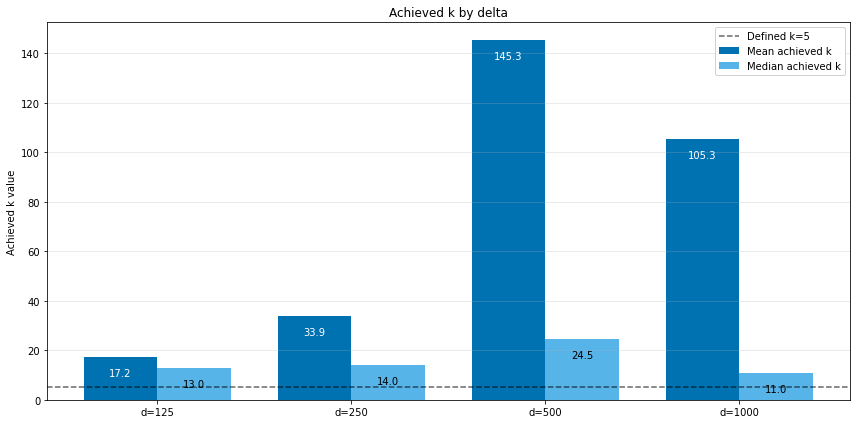

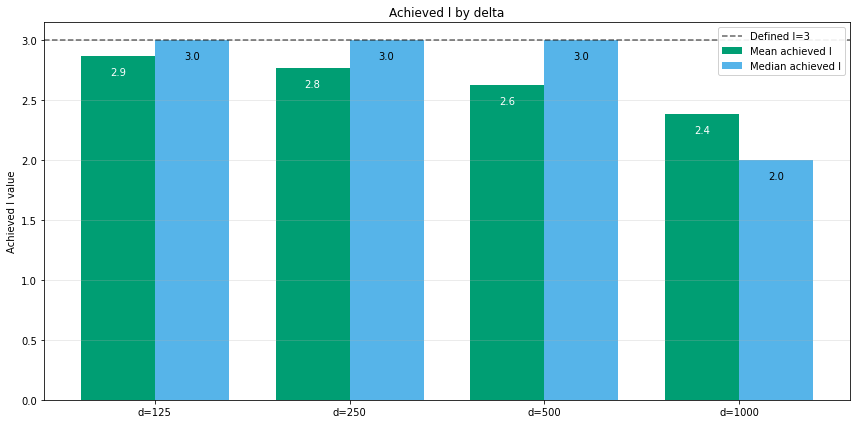

In [16]:
# === Mean & Median achieved per privacy guarantee per delta (d) ===
# Requires `per_file` from the KPI builder cell.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
# --- Bootstrap: create `per_file` if it doesn't exist ---
import os, re, pandas as pd, numpy as np

BASE_DIR = "./data/"  # set to "." if your CSVs are in the notebook folder

def _parse_config(filename: str):
    base = os.path.basename(filename).replace(".csv","")
    parts = re.split(r"[_\-\s]+", base)
    out = {}
    for part in parts:
        p = part.lower()
        if   re.fullmatch(r"k\d+", p): out["k"] = int(p[1:])
        elif re.fullmatch(r"l\d+", p): out["l"] = int(p[1:])
        elif re.fullmatch(r"d\d+", p): out["d"] = int(p[1:])
        elif re.fullmatch(r"delta\d+", p): out["d"] = int(p[5:])
        elif re.fullmatch(r"d=\d+", p): out["d"] = int(p.split("=",1)[1])
        elif p.startswith("beta"): out["beta"] = int(re.sub(r"^beta","",p))
        elif p.startswith("zeta"): out["zeta"] = int(re.sub(r"^zeta","",p))
        elif p.startswith("mu"):   out["mu"]   = int(re.sub(r"^mu","",p))
    return out

def _pick(df_cols, *names):
    norm = {c.lower(): c for c in df_cols}
    for n in names:
        if n.lower() in norm: return norm[n.lower()]
    return None

def _read_privacy_csv(path: str):
    df = pd.read_csv(path)
    # k or l?
    ok = _pick(df.columns, "Observed k"); dk = _pick(df.columns, "Defined k")
    ol = _pick(df.columns, "Observed l"); dl = _pick(df.columns, "Defined l")
    if ok and dk:
        metric, obs_col, def_col = "k", ok, dk
    elif ol and dl:
        metric, obs_col, def_col = "l", ol, dl
    else:
        raise ValueError(f"{os.path.basename(path)} missing Observed/Defined columns")

    observed = pd.to_numeric(df[obs_col], errors="coerce")
    defined  = pd.to_numeric(df[def_col], errors="coerce")

    return metric, observed, defined

def _discover_privacy_files(base_dir: str):
    k_files, l_files = [], []
    for f in os.listdir(base_dir):
        if not f.lower().endswith(".csv"): continue
        name = f.lower()
        if name.startswith("k-anonymity_"): k_files.append(os.path.join(base_dir, f))
        if name.startswith("l-diversity_"): l_files.append(os.path.join(base_dir, f))
    return sorted(k_files) + sorted(l_files)

try:
    per_file  # already exists
except NameError:
    rows = []
    files = _discover_privacy_files(BASE_DIR)
    for path in files:
        try:
            metric, observed, defined = _read_privacy_csv(path)
            params = _parse_config(path)
            rows.append({
                "file": os.path.basename(path),
                "metric": metric,
                "d": params.get("d"),
                "k": params.get("k"),
                "l": params.get("l"),
                "beta": params.get("beta"),
                "zeta": params.get("zeta"),
                "mu": params.get("mu"),
                "observed_mean": float(observed.mean()),
                "observed_median": float(observed.median()),
                "defined_value": float(defined.median() if defined.notna().any() else np.nan),
            })
        except Exception as e:
            print(f"Skipping {os.path.basename(path)} → {e}")
    per_file = pd.DataFrame(rows)
    if per_file.empty:
        raise RuntimeError("No privacy result files found. Set BASE_DIR correctly and ensure files are named k-anonymity_*.csv / l-diversity_*.csv.")

# Reuse your palette
CB_COLORS = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#56B4E9', '#E69F00', '#000000']

def _text_color_for(color_hex: str) -> str:
    r, g, b = mcolors.to_rgb(color_hex)
    lum = 0.299*r + 0.587*g + 0.114*b
    return "white" if lum < 0.5 else "black"

def _label_bars_inside(ax, bars, fmt="{:.1f}", pad_frac=0.03):
    ymin, ymax = ax.get_ylim()
    span = ymax - ymin if ymax > ymin else 1.0
    pad = pad_frac * span
    for bar in bars:
        v = bar.get_height()
        if np.isnan(v): 
            continue
        x = bar.get_x() + bar.get_width()/2
        y = max(v - pad, ymin + 0.015*span)  # keep label visible for small bars
        color = bar.get_facecolor()
        # facecolor may be RGBA -> convert to hex for luminance
        if isinstance(color, tuple):
            color = mcolors.to_hex(color)
        ax.text(x, y, fmt.format(v), ha="center", va="top",
                color=_text_color_for(color), fontsize=10)

def plot_achieved_by_delta(per_file: pd.DataFrame):
    need = {"metric","d","observed_mean","observed_median","defined_value"}
    if per_file.empty or not need.issubset(per_file.columns):
        raise ValueError("per_file is missing required columns. Run the KPI builder first.")

    df = per_file.dropna(subset=["d", "observed_mean", "observed_median"]).copy()
    # Ensure integer-ish d for nicer x labels
    try:
        df["d"] = df["d"].astype(float)
    except Exception:
        pass

    # Aggregate across runs for each (metric, d)
    g = (df.groupby(["metric","d"], dropna=False)
           .agg(achieved_mean=("observed_mean","mean"),
                achieved_median=("observed_median","mean"),   # average of medians across runs
                target_defined=("defined_value","median"),
                n_runs=("file","count"))
           .reset_index())

    if g.empty:
        print("No data to plot.")
        return

    for metric in g["metric"].dropna().unique():
        gm = g[g["metric"] == metric].sort_values("d")
        if gm.empty:
            continue

        x = np.arange(len(gm))
        width = 0.38

        # Choose two distinct, color-blind friendly colors
        col_mean   = CB_COLORS[0] if metric == "k" else CB_COLORS[2]
        col_median = CB_COLORS[4]

        fig, ax = plt.subplots(figsize=(max(12, 1.2*len(gm)), 6))
        bars_mean   = ax.bar(x - width/2, gm["achieved_mean"],   width, label=f"Mean achieved {metric}",   color=col_mean)
        bars_median = ax.bar(x + width/2, gm["achieved_median"], width, label=f"Median achieved {metric}", color=col_median)

        # Target line(s): draw unique defined values seen for this metric
        targets = [t for t in gm["target_defined"].dropna().unique()]
        added_label = False
        for t in targets:
            lbl = f"Defined {metric}={int(t) if float(t).is_integer() else f'{t:.2f}'}"
            ax.axhline(float(t), linestyle="--", color="#000000", alpha=0.6, linewidth=1.5,
                       label=lbl if not added_label else None)
            added_label = True

        # X labels: show d values
        def _fmt_d(val):
            try:
                return f"d={int(val)}" if float(val).is_integer() else f"d={val:g}"
            except Exception:
                return f"d={val}"
        ax.set_xticks(x)
        ax.set_xticklabels([_fmt_d(v) for v in gm["d"]], rotation=0)

        ax.set_title(f"Achieved {metric} by delta") # (mean & median across runs)
        ax.set_ylabel(f"Achieved {metric} value")
        ax.grid(True, axis="y", alpha=0.3)
        ax.legend(framealpha=0.9)
        plt.tight_layout()

        # Put labels INSIDE the bars
        _label_bars_inside(ax, bars_mean,   fmt="{:.1f}")
        _label_bars_inside(ax, bars_median, fmt="{:.1f}")

        plt.show()

# ---- call it ----
plot_achieved_by_delta(per_file)

In [ ]:
# What deltas do we have per metric in per_file?
print("Distinct deltas per metric:")
print(per_file.groupby("metric")["d"].agg(lambda s: sorted(s.dropna().unique().tolist())))

# Show the rows that got DROPPED by the plotting function’s dropna
missing_rows = per_file[ per_file["d"].isna() | per_file["observed_mean"].isna() | per_file["observed_median"].isna() ]
print("\nRows dropped (NaNs in d/observed_mean/observed_median):")
display(missing_rows[["file","metric","d","observed_mean","observed_median"]])

# Count files per (metric, d)
print("\nFile counts per (metric, d):")
display(per_file.groupby(["metric","d"], dropna=False)["file"].count().rename("n_files").reset_index())

Distinct deltas per metric:
metric
k          [125, 250, 500]
l    [125, 250, 500, 1000]
Name: d, dtype: object

Rows dropped (NaNs in d/observed_mean/observed_median):


,file,metric,d,observed_mean,observed_median



File counts per (metric, d):


,metric,d,n_files
0,k,125,1
1,k,250,1
2,k,500,1
3,l,125,1
4,l,250,1
5,l,500,1
6,l,1000,1
